# CSE284 Final Project - Comparing Global Ancestry Analysis Methods on 1000 Genomes Phase 3 Data

In [ ]:
from pathlib import Path
import os

candidate = Path.cwd()
repo_root = None
for path in [candidate, *candidate.parents]:
    if (path / "admixture.sh").exists() and (path / "structure.sh").exists():
        repo_root = path
        break

if repo_root is None:
    raise FileNotFoundError("Cannot locate repo root containing admixture.sh and structure.sh")

os.chdir(repo_root)
print("Current working directory:", os.getcwd())

In [ ]:

# # imports
# import pandas as pd

# # import full 1000 Genomes pop file and filter
# igsr = "1000Genomes/igsr_samples.tsv"
# igsr_df = pd.read_csv(igsr,sep='\t')
# filtered_df = igsr_df[igsr_df['Data collections'].str.contains("phase 1", case=False, na=False)]
# filtered_df = filtered_df.drop(["Sex", "Biosample ID", "Population name", "Population elastic ID", 
#          "Superpopulation code","Superpopulation name"], axis=1)

# # import past-pruning fam file to filter for correct subjects
# fam = "dump/admixture/admixture_chr1.pruned.fam"
# fam_df = pd.read_csv(fam,sep=' ', names=["Name1", "Name2", "a1", "a2", "a3", "a4"])

# # extract all subjects present in fam file
# correct_samples = fam_df["Name1"].tolist()

# # filter 1000 Genomes sample list to only include samples in correct_samples
# new = filtered_df[filtered_df['Sample name'].isin(correct_samples)]

# # convert to correct population format for structure_threader
# new = new.drop(["Sample name", "Data collections"], axis=1)
# value_counts = new['Population code'].value_counts()

# # Creating a new DataFrame for pop counts
# counts_df = pd.DataFrame({'Population': value_counts.index, 'count': value_counts.values})
# counts_df = counts_df.sort_values(by="Population", ascending=True)
# counts_df['location'] = range(1, len(counts_df) + 1)
# #counts_df['count'] = counts_df['count'].astype(int)
# #counts_df['location'] = counts_df['location'].astype(int)

# # export to csv
# counts_df.to_csv('dump/structure/structure_pop_file.tsv', sep='\t', index=False)

In [ ]:
# Run full pipelines after population file is prepared
!bash admixture.sh
!bash structure.sh

/tmp/ipykernel_8292/3952545316.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv("dump/admixture/admixture_ALL.pruned.%s.Q"%K, delim_whitespace=True, header=None)
/tmp/ipykernel_8292/3952545316.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv("dump/admixture/admixture_ALL.pruned.%s.Q"%K, delim_whitespace=True, header=None)
/tmp/ipykernel_8292/3952545316.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv("dump/admixture/admixture_ALL.pruned.%s.Q"%K, delim_whitespace=True, header=None)


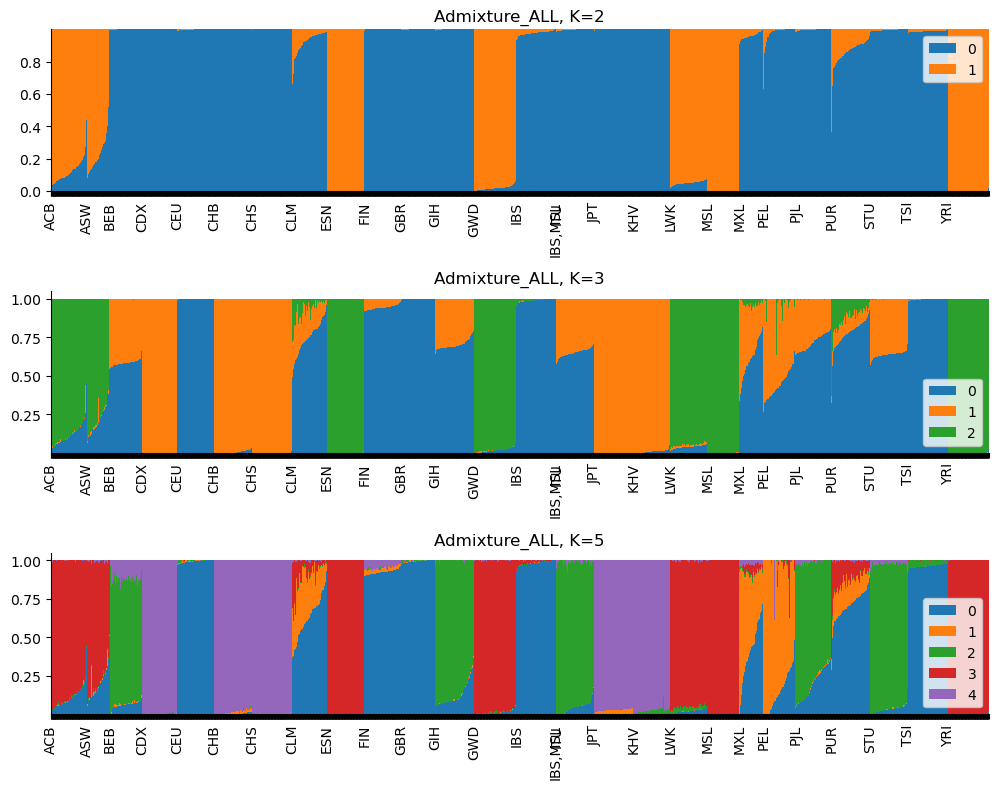

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt

sampleinfo = pd.read_csv("1000Genomes/igsr_samples.tsv", sep="\t")
sample_to_pop = dict(zip(list(sampleinfo["Sample name"]), list(sampleinfo["Population code"])))
samples = [line.split()[0] for line in open("dump/admixture/admixture_ALL.pruned.fam", "r").readlines()]
pops = [sample_to_pop.get(item, "NA") for item in samples]

fig = plt.figure()
fig.set_size_inches((10, 8))

plotind = 1
for K in [2, 3, 5]:
    ax = fig.add_subplot(3, 1, plotind)

    data = pd.read_csv("dump/admixture/admixture_ALL.pruned.%s.Q" % K, sep=r"\s+", header=None)
    cols = list(data.columns)
    data["sample"] = samples
    data["pop"] = pops
    data = data.sort_values(["pop"] + cols)
    data.plot.bar(stacked=True, ax=ax, width=1)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.set_ticks_position('left')
    ax.xaxis.set_ticks_position('bottom')

    # Only plot label for first sample in each pop
    xticklabels = []
    currpop = ""
    for i in range(data.shape[0]):
        if data["pop"].values[i] == currpop:
            xticklabels.append("")
        else:
            xticklabels.append(data["pop"].values[i])
            currpop = data["pop"].values[i]
    ax.set_xticklabels(xticklabels)
    ax.set_title(f"Admixture_ALL, K={K}")

    plotind += 1
fig.tight_layout()

## Faststructure

/tmp/ipykernel_21804/591055946.py:16: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv("dump/structure/structure_ALL/fS_run_K.%s.meanQ"%K, delim_whitespace=True, header=None)
/tmp/ipykernel_21804/591055946.py:16: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv("dump/structure/structure_ALL/fS_run_K.%s.meanQ"%K, delim_whitespace=True, header=None)
/tmp/ipykernel_21804/591055946.py:16: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv("dump/structure/structure_ALL/fS_run_K.%s.meanQ"%K, delim_whitespace=True, header=None)


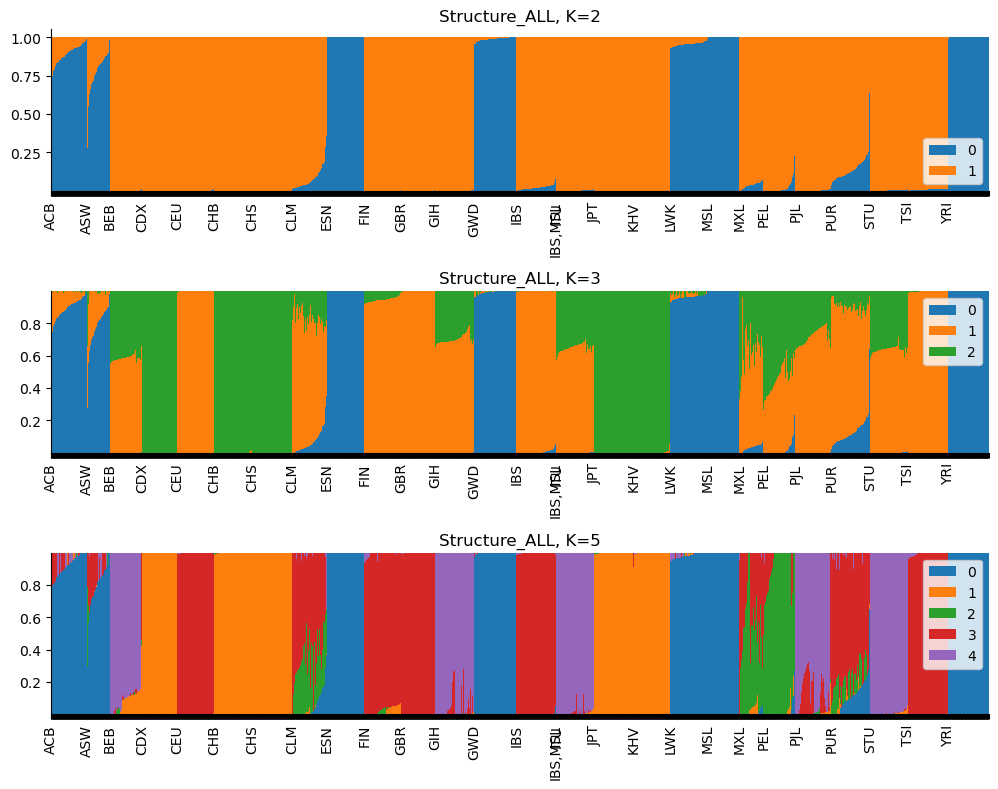

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
sampleinfo = pd.read_csv("1000Genomes/igsr_samples.tsv", sep="\t")
sample_to_pop = dict(zip(list(sampleinfo["Sample name"]), list(sampleinfo["Population code"])))
samples = [line.split()[0] for line in open("dump/structure/structure_ALL.pruned.fam", "r").readlines()]
pops = [sample_to_pop.get(item, "NA") for item in samples]

fig = plt.figure()
fig.set_size_inches((10, 8))

plotind = 1
for K in [2, 3, 5]:
    ax = fig.add_subplot(3, 1, plotind)

    data = pd.read_csv("dump/structure/structure_ALL/fS_run_K.%s.meanQ" % K, sep=r"\s+", header=None)
    cols = list(data.columns)
    data["sample"] = samples
    data["pop"] = pops
    data = data.sort_values(["pop"] + cols)
    data.plot.bar(stacked=True, ax=ax, width=1)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.set_ticks_position('left')
    ax.xaxis.set_ticks_position('bottom')

    # Only plot label for first sample in each pop
    xticklabels = []
    currpop = ""
    for i in range(data.shape[0]):
        if data["pop"].values[i] == currpop:
            xticklabels.append("")
        else:
            xticklabels.append(data["pop"].values[i])
            currpop = data["pop"].values[i]
    ax.set_xticklabels(xticklabels)
    ax.set_title(f"Structure_ALL, K={K}")

    plotind += 1
fig.tight_layout()

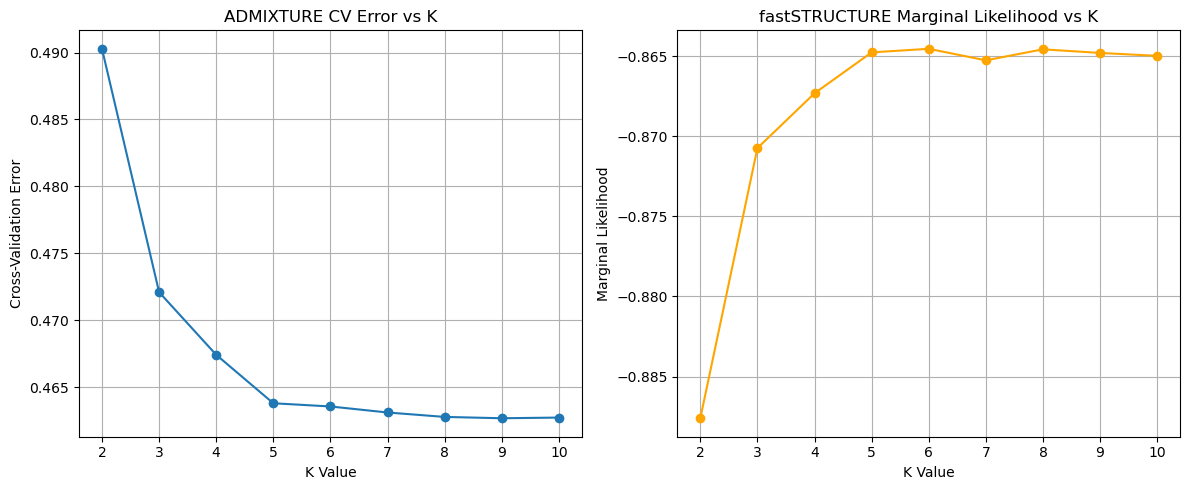

In [4]:
import matplotlib.pyplot as plt

# Data
k_values = list(range(2, 11))
cv_errors = [0.49028, 0.47210, 0.46742, 0.46380, 0.46356, 0.46311, 0.46278, 0.46268, 0.46273]
ml = [-0.8876028770, -0.8707424390, -0.8673214721, -0.8647675676,
      -0.8645441912, -0.8652638589, -0.8645767869,
      -0.8648020952, -0.8649840697]

# Create two subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ----- Subplot 1: ADMIXTURE CV error -----
axes[0].plot(k_values, cv_errors, marker='o')
axes[0].set_xlabel("K Value")
axes[0].set_ylabel("Cross-Validation Error")
axes[0].set_title("ADMIXTURE CV Error vs K")
axes[0].set_xticks(k_values)
axes[0].grid(True)

# ----- Subplot 2: fastSTRUCTURE Marginal Likelihood -----
axes[1].plot(k_values, ml, marker='o', color='orange')
axes[1].set_xlabel("K Value")
axes[1].set_ylabel("Marginal Likelihood")
axes[1].set_title("fastSTRUCTURE Marginal Likelihood vs K")
axes[1].set_xticks(k_values)
axes[1].grid(True)

plt.tight_layout()
plt.show()